# SARIMA — Seasonal ARIMA

## 1. What is SARIMA?

**SARIMA** stands for:

> **Seasonal AutoRegressive Integrated Moving Average**

SARIMA is an extension of **ARIMA** designed to model time series that contain **seasonal patterns**.

Seasonality occurs when a pattern repeats at a fixed interval.

Examples:

* Monthly sales repeating every year
* Daily electricity demand repeating every week
* Hourly traffic repeating every day
* Quarterly revenue repeating every year

The general form of SARIMA is:

$$
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
$$

The first set of parameters,

$$
(p,d,q)
$$

represents the **non-seasonal component**.

The second set,

$$
(P,D,Q)_s
$$

represents the **seasonal component**.

---

# 2. Why Do We Need SARIMA?

ARIMA can model:

* Autoregressive relationships
* Differencing
* Moving-average relationships

However, consider monthly sales where the same pattern repeats every year:

```text
2019:  Jan  Feb  Mar  ...  Dec
         ↓    ↓    ↓        ↓
        Low  ...  ...      High

2020:  Jan  Feb  Mar  ...  Dec
         ↓    ↓    ↓        ↓
        Low  ...  ...      High

2021:  Jan  Feb  Mar  ...  Dec
         ↓    ↓    ↓        ↓
        Low  ...  ...      High
```

For monthly data with yearly seasonality, the seasonal period is:

$$
s = 12
$$

Therefore, the current observation may depend not only on:

$$
Y_{t-1}
$$

but also on:

$$
Y_{t-12}
$$

because $Y_{t-12}$ represents the observation from the **same month in the previous year**.

SARIMA explicitly models this seasonal structure.

---

# 3. SARIMA Notation

SARIMA is written as:

$$
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
$$

There are two groups of parameters.

### Non-seasonal parameters

$$
\boxed{(p,d,q)}
$$

### Seasonal parameters

$$
\boxed{(P,D,Q)_s}
$$

| Parameter | Meaning                         |
| --------- | ------------------------------- |
| $p$       | Non-seasonal AR order           |
| $d$       | Non-seasonal differencing order |
| $q$       | Non-seasonal MA order           |
| $P$       | Seasonal AR order               |
| $D$       | Seasonal differencing order     |
| $Q$       | Seasonal MA order               |
| $s$       | Seasonal period                 |

---

# 4. Understanding the Seasonal Period $(s)$

The parameter $s$ represents the number of observations in one complete seasonal cycle.

| Data Frequency | Typical Seasonality | $s$ |
| -------------- | ------------------- | --: |
| Monthly        | Yearly              |  12 |
| Quarterly      | Yearly              |   4 |
| Daily          | Weekly              |   7 |
| Hourly         | Daily               |  24 |
| Weekly         | Yearly              |  52 |

For monthly data with yearly seasonality:

$$
\boxed{s=12}
$$

Therefore:

$$
\boxed{
SARIMA(p,d,q)(P,D,Q)_{12}
}
$$

---

# 5. SARIMA Has Two Parts

SARIMA can be thought of as:

$$
\boxed{
SARIMA =
\text{Non-seasonal ARIMA}
+
\text{Seasonal Component}
}
$$

The non-seasonal part is:

$$
(p,d,q)
$$

The seasonal part is:

$$
(P,D,Q)_s
$$

Conceptually:

```text
                         SARIMA
                            │
              ┌─────────────┴─────────────┐
              │                           │
        Non-seasonal                  Seasonal
           (p,d,q)                   (P,D,Q)s
              │                           │
        ┌─────┼─────┐               ┌─────┼─────┐
        │     │     │               │     │     │
       AR     I     MA             SAR    SI    SMA
        p     d     q                P     D     Q
```

---

# 6. Seasonal AR — $(P)$

The **seasonal AR component** models the relationship between the current observation and observations from previous seasonal cycles.

For monthly data:

$$
s=12
$$

A seasonal AR(1) component uses:

$$
Y_{t-12}
$$

rather than only:

$$
Y_{t-1}
$$

A simplified seasonal AR(1) relationship is:

$$
\boxed{
Y_t = \Phi_1 Y_{t-12} + \epsilon_t
}
$$

where:

* $\Phi_1$ = seasonal AR coefficient
* $Y_{t-12}$ = observation from the previous seasonal cycle
* $\epsilon_t$ = error term

For example, if:

$$
\Phi_1=0.7
$$

then:

$$
Y_t=0.7Y_{t-12}+\epsilon_t
$$

This means the current month's value is influenced by the corresponding month from the previous year.

```text
January 2025   ───────► January 2026
February 2025  ───────► February 2026
March 2025     ───────► March 2026
```

Therefore:

$$
\boxed{P=1}
$$

means one seasonal AR term.

---

# 7. Seasonal Differencing — $(D)$

Ordinary differencing removes non-seasonal trends:

$$
\boxed{
\Delta Y_t = Y_t-Y_{t-1}
}
$$

Seasonal differencing removes repeating seasonal patterns.

The seasonal difference is:

$$
\boxed{
\Delta_sY_t=Y_t-Y_{t-s}
}
$$

For monthly data:

$$
\boxed{
\Delta_{12}Y_t=Y_t-Y_{t-12}
}
$$

This compares each observation with the corresponding observation from the previous year.

### Example

Suppose:

```text
January 2024 = 100
January 2025 = 130
```

Then:

$$
130-100=30
$$

Similarly:

$$
February_{2025}-February_{2024}
$$

and:

$$
March_{2025}-March_{2024}
$$

and so on.

If one seasonal difference is required:

$$
\boxed{D=1}
$$

---

# 8. Normal Differencing vs Seasonal Differencing

This distinction is extremely important.

## Normal Differencing

Normal differencing compares an observation with the immediately preceding observation:

$$
\boxed{
\Delta Y_t=Y_t-Y_{t-1}
}
$$

Conceptually:

```text
This month
     │
     ▼
Previous month
```

For example:

```text
March → April
```

---

## Seasonal Differencing

Seasonal differencing compares an observation with the observation from the previous seasonal cycle:

$$
\boxed{
\Delta_sY_t=Y_t-Y_{t-s}
}
$$

For monthly data:

$$
\boxed{
\Delta_{12}Y_t=Y_t-Y_{t-12}
}
$$

Conceptually:

```text
This month
     │
     ▼
Same month last year
```

For example:

```text
April 2025 → April 2026
```

---

# 9. Seasonal MA — $(Q)$

The **seasonal MA component** uses forecast errors from previous seasonal cycles.

For monthly data, a seasonal MA(1) component uses:

$$
\epsilon_{t-12}
$$

A simplified representation is:

$$
\boxed{
Y_t=\epsilon_t+\Theta_1\epsilon_{t-12}
}
$$

where:

* $\Theta_1$ = seasonal MA coefficient
* $\epsilon_t$ = current error
* $\epsilon_{t-12}$ = error from the previous seasonal cycle

Therefore:

$$
\boxed{Q=1}
$$

means one seasonal MA term.

> **Important:** Seasonal MA uses past **forecast errors**, not past observations.

---

# 10. Normal vs Seasonal Components

Suppose we have monthly data.

### Normal AR(1)

Uses:

$$
Y_{t-1}
$$

This represents a short-term relationship:

```text
Previous month → Current month
```

### Seasonal AR(1)

Uses:

$$
Y_{t-12}
$$

This represents a yearly seasonal relationship:

```text
Same month last year → Current month
```

Similarly:

### Normal MA(1)

Uses:

$$
\epsilon_{t-1}
$$

### Seasonal MA(1)

Uses:

$$
\epsilon_{t-12}
$$

Therefore:

```text
Normal relationship:

t ← t - 1


Seasonal relationship:

t ← t - s
```

For monthly data:

```text
t ← t - 12
```

---

# 11. Example: SARIMA(1,1,1)(1,1,1)₁₂

Consider:

$$
\boxed{
SARIMA(1,1,1)(1,1,1)_{12}
}
$$

## Non-seasonal component

$$
(p,d,q)=(1,1,1)
$$

Therefore:

* $p=1$ → one non-seasonal AR term
* $d=1$ → first-order non-seasonal differencing
* $q=1$ → one non-seasonal MA term

## Seasonal component

$$
(P,D,Q)=(1,1,1)
$$

Therefore:

* $P=1$ → one seasonal AR term
* $D=1$ → one seasonal difference
* $Q=1$ → one seasonal MA term

## Seasonal period

$$
s=12
$$

because the data is monthly with yearly seasonality.

---

# 12. ACF and PACF in SARIMA

ACF and PACF can help identify both **non-seasonal** and **seasonal** components.

For ordinary ARIMA:

$$
\boxed{
PACF \rightarrow p
}
$$

$$
\boxed{
ACF \rightarrow q
}
$$

For SARIMA, we also examine spikes at **seasonal lags**.

For monthly data, important seasonal lags are:

$$
12,\ 24,\ 36,\ldots
$$

---

# 13. Seasonal ACF

Suppose the ACF shows strong spikes at seasonal lags:

```text
Lag       ACF

1         ███
2         ██
3         █
...
12        ███████
24        █████
36        ███
```

Strong spikes at:

$$
12,\ 24,\ 36
$$

suggest that the series contains seasonal dependence.

This may indicate the need for a seasonal component.

As a rule of thumb:

$$
\boxed{
\text{Seasonal ACF} \rightarrow Q
}
$$

---

# 14. Seasonal PACF

Similarly, if the PACF has strong spikes at seasonal lags:

```text
Lag       PACF

1         ██
2         █
...
12        ███████
24        ██
```

this can suggest a seasonal AR component.

As a rule of thumb:

$$
\boxed{
\text{Seasonal PACF} \rightarrow P
}
$$

These ACF/PACF rules are **guidelines**, not strict mathematical rules.

---

# 15. ACF/PACF Summary for SARIMA

| Parameter | Component                 | Identification Method             |
| --------- | ------------------------- | --------------------------------- |
| $p$       | Non-seasonal AR           | PACF                              |
| $d$       | Non-seasonal differencing | Stationarity / ADF                |
| $q$       | Non-seasonal MA           | ACF                               |
| $P$       | Seasonal AR               | Seasonal PACF                     |
| $D$       | Seasonal differencing     | Seasonal stationarity             |
| $Q$       | Seasonal MA               | Seasonal ACF                      |
| $s$       | Seasonal period           | Data frequency / domain knowledge |

> **Note:** ACF and PACF provide candidate values for the orders. They should be combined with model diagnostics, AIC/BIC, and out-of-sample validation.

---

# 16. ARIMA vs SARIMA

## ARIMA

$$
\boxed{
ARIMA(p,d,q)
}
$$

ARIMA handles:

* Non-seasonal AR
* Non-seasonal differencing
* Non-seasonal MA

---

## SARIMA

$$
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
$$

SARIMA handles:

* Non-seasonal AR
* Non-seasonal differencing
* Non-seasonal MA
* Seasonal AR
* Seasonal differencing
* Seasonal MA

Therefore:

$$
\boxed{
SARIMA = ARIMA + Seasonal\ Structure
}
$$

---

# 17. Example: Monthly Sales

Suppose we have monthly sales:

```text
2019:
Jan  Feb  Mar  ...  Dec
 ↓    ↓    ↓        ↓
Low  ...  ...     High

2020:
Jan  Feb  Mar  ...  Dec
 ↓    ↓    ↓        ↓
Low  ...  ...     High

2021:
Jan  Feb  Mar  ...  Dec
 ↓    ↓    ↓        ↓
Low  ...  ...     High
```

There may be:

1. An overall trend
2. A yearly seasonal pattern

For monthly data:

$$
s=12
$$

A possible model is:

$$
\boxed{
SARIMA(1,1,1)(1,1,1)_{12}
}
$$

This model can capture both:

### Short-term relationship

$$
Y_{t-1}
$$

and:

### Yearly seasonal relationship

$$
Y_{t-12}
$$

---

# 18. SARIMA in Python

`statsmodels` provides SARIMA models through the `SARIMAX` class.

```python
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    series_3,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

model_fit = model.fit()

print(model_fit.summary())
```

The important arguments are:

```python
order=(p, d, q)
```

and:

```python
seasonal_order=(P, D, Q, s)
```

---

# 19. Understanding the Python Code

For:

```python
order=(1, 1, 1)
```

we have:

```text
p = 1 → Non-seasonal AR order
d = 1 → Non-seasonal differencing order
q = 1 → Non-seasonal MA order
```

For:

```python
seasonal_order=(1, 1, 1, 12)
```

we have:

```text
P = 1  → Seasonal AR order
D = 1  → Seasonal differencing order
Q = 1  → Seasonal MA order
s = 12 → Seasonal period
```

Therefore, the complete model is:

$$
\boxed{
SARIMA(1,1,1)(1,1,1)_{12}
}
$$

---

# 20. Forecasting Using SARIMA

After fitting the model, we can forecast future observations:

```python
forecast = model_fit.forecast(steps=12)

print(forecast)
```

For monthly data:

```python
forecast = model_fit.forecast(steps=12)
```

means:

> Forecast the next 12 months.

---

# 21. Plotting the SARIMA Forecast

```python
import matplotlib.pyplot as plt

forecast = model_fit.forecast(steps=12)

plt.figure(figsize=(12, 5))

plt.plot(
    series_3,
    label="Actual"
)

plt.plot(
    forecast,
    label="Forecast"
)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("SARIMA Forecast")

plt.legend()
plt.show()
```

---

# 22. SARIMA Model Selection

We usually do not know the correct values of:

$$
p,d,q,P,D,Q
$$

beforehand.

Therefore, we can create several candidate models.

For example:

$$
SARIMA(1,1,1)(1,1,1)_{12}
$$

$$
SARIMA(2,1,1)(1,1,1)_{12}
$$

$$
SARIMA(1,1,2)(1,1,1)_{12}
$$

$$
SARIMA(1,1,1)(2,1,1)_{12}
$$

These candidate models can then be compared.

---

# 23. AIC and BIC for SARIMA

AIC and BIC can also be used to compare SARIMA models.

### AIC

$$
\boxed{
AIC=-2\ln(L)+2k
}
$$

### BIC

$$
\boxed{
BIC=-2\ln(L)+k\ln(n)
}
$$

For both criteria:

$$
\boxed{
\text{Lower value is better}
}
$$

For example:

| Model                  | AIC | BIC |
| ---------------------- | --: | --: |
| SARIMA(1,1,1)(1,1,1)₁₂ | 520 | 535 |
| SARIMA(2,1,1)(1,1,1)₁₂ | 515 | 532 |
| SARIMA(1,1,2)(1,1,1)₁₂ | 518 | 534 |

Both AIC and BIC prefer:

$$
\boxed{
SARIMA(2,1,1)(1,1,1)_{12}
}
$$

because it has the lowest value for both criteria.

> **Important:** AIC/BIC should not be the only basis for selecting the final forecasting model. Residual diagnostics and out-of-sample forecast performance should also be considered.

---

# 24. SARIMA Residual Diagnostics

After fitting SARIMA, we should examine the residuals.

The residual is:

$$
\boxed{
e_t=Y_t-\hat{Y}_t
}
$$

where:

* $Y_t$ = actual observation
* $\hat{Y}_t$ = fitted or predicted value
* $e_t$ = residual

A good SARIMA model should leave residuals that behave approximately like **white noise**.

We want:

$$
E(e_t)\approx0
$$

and ideally:

* No obvious trend
* Approximately constant variance
* No significant autocorrelation
* No remaining seasonal pattern

---

# 25. Residual ACF

We can examine the residual ACF using:

```python
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

residuals = model_fit.resid.dropna()

plot_acf(
    residuals,
    lags=36
)

plt.title("Residual ACF")
plt.show()
```

For monthly data, pay particular attention to:

$$
12,\ 24,\ 36
$$

If strong spikes remain at these seasonal lags, the SARIMA model may not have captured all the seasonal structure.

---

# 26. Ljung-Box Test for Residuals

The **Ljung-Box test** can also be used to check whether residual autocorrelation remains.

```python
from statsmodels.stats.diagnostic import acorr_ljungbox

result = acorr_ljungbox(
    model_fit.resid.dropna(),
    lags=[12, 24],
    return_df=True
)

print(result)
```

The hypotheses are:

$$
H_0:
\text{Residuals are independently distributed}
$$

$$
H_1:
\text{Residuals contain autocorrelation}
$$

A large p-value means we do not have sufficient evidence to reject $H_0$.

Therefore, ideally:

$$
\boxed{
p\text{-value} > 0.05
}
$$

at the selected lags.

> **Important:** A large p-value does not prove that residuals are perfect white noise; it simply means the test does not find statistically significant autocorrelation at those lags.

---

# 27. Complete SARIMA Workflow

```text
                 Original Time Series
                          │
                          ▼
                     Plot Series
                          │
                          ▼
              Check Trend + Seasonality
                          │
                          ▼
                 Determine Seasonality
                          │
                          ▼
                    Check Stationarity
                          │
                          ▼
                       ADF Test
                          │
                          ▼
                    Determine d and D
                          │
                          ▼
                      ACF + PACF
                          │
             ┌────────────┴────────────┐
             ▼                         ▼
       Non-seasonal                 Seasonal
        patterns                   patterns
             │                         │
        ┌────┴────┐               ┌────┴────┐
        ▼         ▼               ▼         ▼
        p         q               P         Q
        │         │               │         │
        └────┬────┘               └────┬────┘
             │                         │
             └────────────┬────────────┘
                          ▼
                  Candidate SARIMA
                       Models
                          │
                          ▼
                      AIC / BIC
                          │
                          ▼
                  Select Candidate
                          │
                          ▼
                 Residual Diagnostics
                          │
                          ▼
                  Test Set Validation
                          │
                          ▼
                       Forecast
```

---

# 28. ARIMA vs SARIMA — Complete Comparison

| Feature                        | ARIMA | SARIMA |
| ------------------------------ | ----- | ------ |
| Non-seasonal AR                | $p$   | $p$    |
| Non-seasonal differencing      | $d$   | $d$    |
| Non-seasonal MA                | $q$   | $q$    |
| Seasonal AR                    | ❌     | $P$    |
| Seasonal differencing          | ❌     | $D$    |
| Seasonal MA                    | ❌     | $Q$    |
| Seasonal period                | ❌     | $s$    |
| Handles non-stationarity       | ✅     | ✅      |
| Handles seasonality explicitly | ❌     | ✅      |

---

# 29. ARIMA vs SARIMA Example

Suppose monthly sales have a yearly seasonal pattern.

ARIMA might capture a short-term relationship such as:

$$
Y_t \leftarrow Y_{t-1}
$$

SARIMA can capture both:

### Short-term relationship

$$
Y_t \leftarrow Y_{t-1}
$$

### Seasonal relationship

$$
Y_t \leftarrow Y_{t-12}
$$

Therefore:

$$
\boxed{
ARIMA \rightarrow \text{Non-seasonal patterns}
}
$$

$$
\boxed{
SARIMA \rightarrow \text{Non-seasonal + Seasonal patterns}
}
$$

---

# 30. SARIMA and the Time Series You Created

In your earlier example, you created a monthly time series using:

```python
seasonal_multipliers = [
    110, 130, 120, 150,
    190, 230, 210, 280,
    200, 170, 150, 120
]
```

There are **12 seasonal multipliers**, representing a repeating yearly pattern.

Since the data is monthly:

$$
\boxed{s=12}
$$

Therefore, this is the type of time series where SARIMA can be appropriate.

The seasonal pattern repeats every:

$$
12\text{ observations}
$$

Therefore, SARIMA can model relationships such as:

$$
Y_t \leftrightarrow Y_{t-12}
$$

For example:

```text
January 2020  ─────► January 2021
February 2020 ─────► February 2021
March 2020    ─────► March 2021
```

---

# 31. Important Point: Trend vs Seasonality

It is important to distinguish **trend** from **seasonality**.

### Trend

A long-term upward or downward movement:

```text
       *
      *
    *
   *
 *
──────────────────────► Time
```

Differencing can help remove non-seasonal trend:

$$
\Delta Y_t=Y_t-Y_{t-1}
$$

This is controlled by:

$$
d
$$

---

### Seasonality

A pattern that repeats at a fixed interval:

```text
    /\      /\      /\
   /  \    /  \    /  \
__/    \__/    \__/    \__
──────────────────────────► Time
```

Seasonal differencing can remove persistent seasonal structure:

$$
\Delta_sY_t=Y_t-Y_{t-s}
$$

This is controlled by:

$$
D
$$

Therefore:

$$
\boxed{
d \rightarrow \text{Non-seasonal differencing}
}
$$

$$
\boxed{
D \rightarrow \text{Seasonal differencing}
}
$$

---

# 32. Key Relationship Between ACF, PACF and SARIMA

For ordinary ARIMA:

$$
\boxed{
PACF \rightarrow p
}
$$

$$
\boxed{
ACF \rightarrow q
}
$$

For seasonal components:

$$
\boxed{
\text{Seasonal PACF} \rightarrow P
}
$$

$$
\boxed{
\text{Seasonal ACF} \rightarrow Q
}
$$

For differencing:

$$
\boxed{
\text{Stationarity analysis} \rightarrow d,D
}
$$

For model selection:

$$
\boxed{
AIC/BIC \rightarrow \text{Compare Candidate Models}
}
$$

For final evaluation:

$$
\boxed{
RMSE/MAE \rightarrow \text{Forecast Accuracy}
}
$$

---

# 33. Complete Model Selection Logic

A useful way to remember the entire process is:

```text
                  Time Series
                       │
                       ▼
             Identify Seasonality
                       │
                       ▼
                    Choose s
                       │
                       ▼
              Check Stationarity
                       │
                       ▼
              Determine d and D
                       │
                       ▼
                  ACF + PACF
                       │
          ┌────────────┴────────────┐
          ▼                         ▼
     Non-seasonal                Seasonal
          │                         │
      p and q                    P and Q
          │                         │
          └────────────┬────────────┘
                       ▼
                Candidate Models
                       │
                       ▼
                   AIC / BIC
                       │
                       ▼
              Residual Diagnostics
                       │
                       ▼
              Out-of-Sample Testing
                       │
                       ▼
                    Forecast
```

---

# 34. Final Summary

The most important SARIMA formula is:

$$
\boxed{
SARIMA(p,d,q)(P,D,Q)_s
}
$$

where:

$$
\boxed{
p=\text{Non-seasonal AR order}
}
$$

$$
\boxed{
d=\text{Non-seasonal differencing order}
}
$$

$$
\boxed{
q=\text{Non-seasonal MA order}
}
$$

$$
\boxed{
P=\text{Seasonal AR order}
}
$$

$$
\boxed{
D=\text{Seasonal differencing order}
}
$$

$$
\boxed{
Q=\text{Seasonal MA order}
}
$$

$$
\boxed{
s=\text{Seasonal period}
}
$$

For monthly data with yearly seasonality:

$$
\boxed{s=12}
$$

A common example is:

$$
\boxed{
SARIMA(1,1,1)(1,1,1)_{12}
}
$$

---

# 35. Easy Way to Remember

## ARIMA

$$
\boxed{
(p,d,q)
}
$$

Think:

> **Past values + Differencing + Past errors**

---

## SARIMA

$$
\boxed{
(p,d,q)(P,D,Q)_s
}
$$

Think:

> **ARIMA + Seasonal AR + Seasonal Differencing + Seasonal MA**

---

## Complete Workflow

$$
\boxed{
\text{Identify Seasonality}
\rightarrow
s
\rightarrow
\text{Stationarity}
\rightarrow
d,D
\rightarrow
ACF/PACF
\rightarrow
p,q,P,Q
\rightarrow
AIC/BIC
\rightarrow
\text{Residual Diagnostics}
\rightarrow
\text{Validation}
\rightarrow
\text{Forecast}
}
$$

---

# 36. One-Page Cheat Sheet

| Concept      | Meaning                             | Typical Tool / Interpretation     |
| ------------ | ----------------------------------- | --------------------------------- |
| $p$          | Non-seasonal AR order               | PACF                              |
| $d$          | Non-seasonal differencing           | ADF / stationarity                |
| $q$          | Non-seasonal MA order               | ACF                               |
| $P$          | Seasonal AR order                   | Seasonal PACF                     |
| $D$          | Seasonal differencing               | Seasonal stationarity             |
| $Q$          | Seasonal MA order                   | Seasonal ACF                      |
| $s$          | Seasonal period                     | Data frequency / domain knowledge |
| AIC          | Fit + complexity criterion          | Lower is better                   |
| BIC          | Fit + stronger complexity penalty   | Lower is better                   |
| Residual ACF | Remaining autocorrelation           | Ideally no significant spikes     |
| Ljung-Box    | Residual autocorrelation test       | Ideally large p-value             |
| MAE          | Absolute forecast error             | Lower is better                   |
| RMSE         | Squared-error-based forecast metric | Lower is better                   |

### The key relationships

$$
\boxed{
ADF \rightarrow d,D
}
$$

$$
\boxed{
PACF \rightarrow p
}
$$

$$
\boxed{
ACF \rightarrow q
}
$$

$$
\boxed{
\text{Seasonal PACF} \rightarrow P
}
$$

$$
\boxed{
\text{Seasonal ACF} \rightarrow Q
}
$$

$$
\boxed{
AIC/BIC \rightarrow \text{Model Comparison}
}
$$

$$
\boxed{
\text{Residual Diagnostics} \rightarrow \text{Model Adequacy}
}
$$

$$
\boxed{
MAE/RMSE \rightarrow \text{Forecast Accuracy}
}
$$

> **Final principle:** A good SARIMA model is not simply the model with the lowest AIC or BIC. Ideally, it should have reasonable model complexity, white-noise residuals, and strong out-of-sample forecasting performance.


In [9]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from pandas import Series
from pmdarima import auto_arima

In [40]:
series = pd.read_csv('city_day.csv')
series_delhi = series.loc[series['City'] == 'Delhi']
ts_delhi = series_delhi[['Date','AQI']]
#converting 'Date' column to type 'datetime' so that indexing can happen later
ts_delhi['Date'] = pd.to_datetime(ts_delhi['Date'])

In [41]:
ts_delhi.isnull().sum()
ts_delhi = ts_delhi.dropna()
ts_delhi.isnull().sum()

Date    0
AQI     0
dtype: int64

In [42]:
ts_delhi

,Date,AQI
10229,2015-01-01,472.0
10230,2015-01-02,454.0
10231,2015-01-03,143.0
10232,2015-01-04,319.0
10233,2015-01-05,325.0
...,...,...
12233,2020-06-27,112.0
12234,2020-06-28,196.0
12235,2020-06-29,233.0
12236,2020-06-30,114.0


In [43]:
ts_delhi = ts_delhi.set_index('Date')
ts_delhi

,AQI
Date,
2015-01-01,472.0
2015-01-02,454.0
2015-01-03,143.0
2015-01-04,319.0
2015-01-05,325.0
...,...
2020-06-27,112.0
2020-06-28,196.0
2020-06-29,233.0


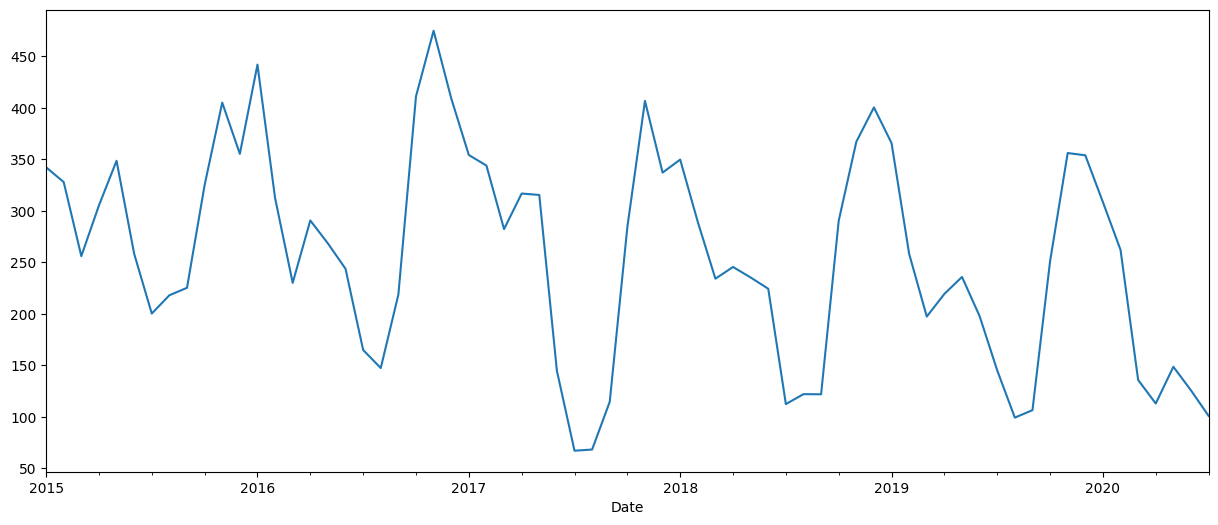

In [45]:
ts_month_avg = ts_delhi['AQI'].resample('MS').mean()
ts_month_avg.plot(figsize = (15, 6))
plt.show()

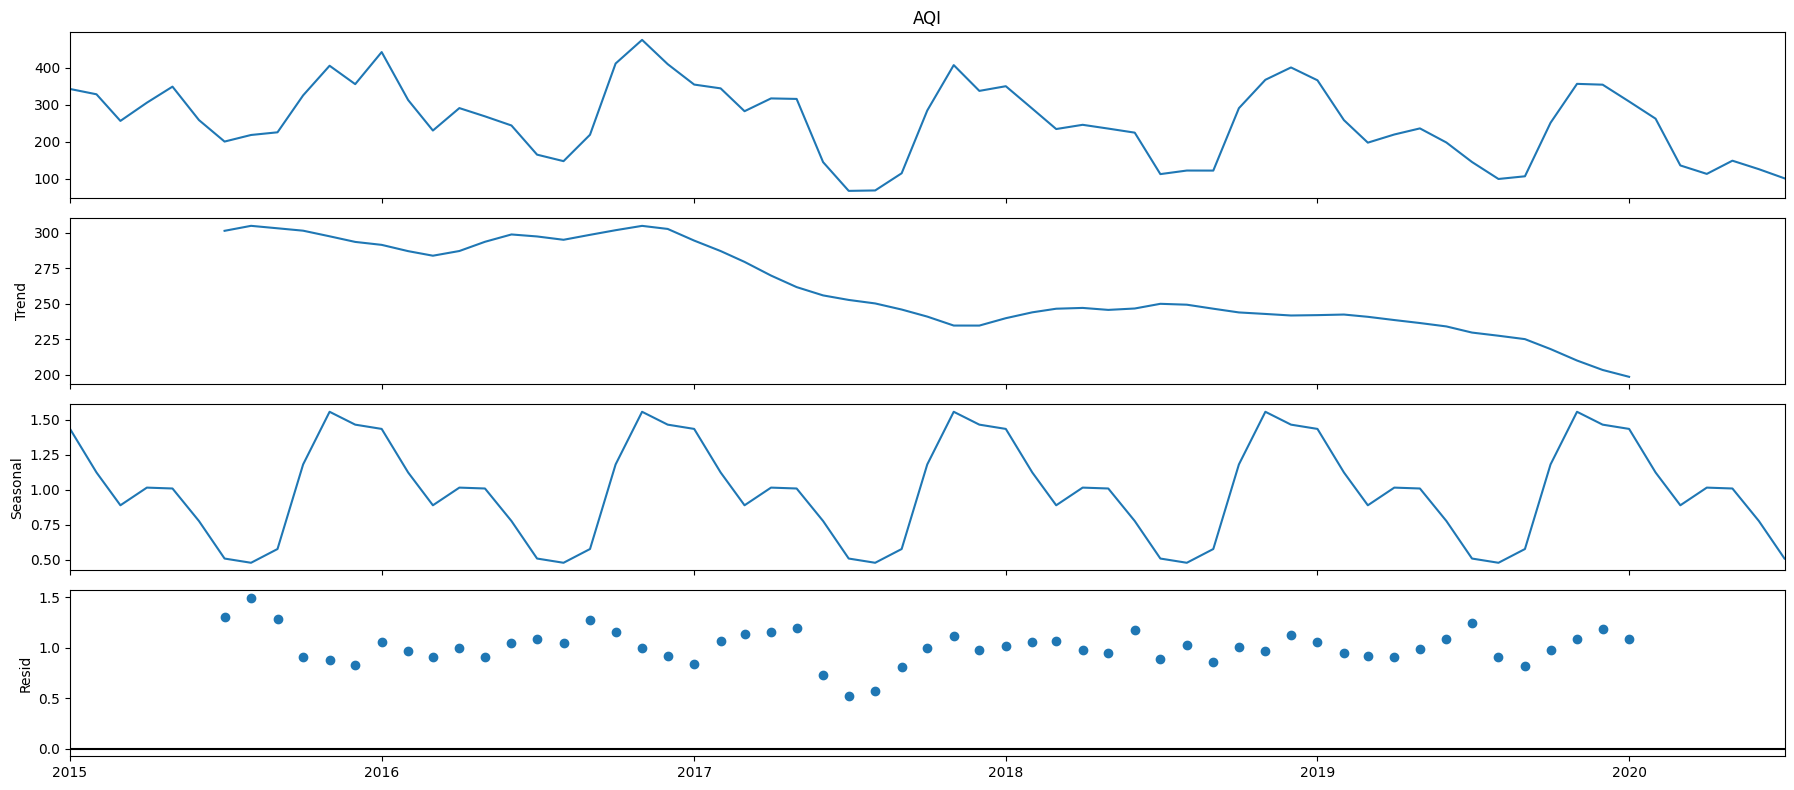

In [46]:
from pylab import rcParams
rcParams['figure.figsize'] = 18, 8
decomposition = sm.tsa.seasonal_decompose(ts_month_avg, model='multiplicative')
fig = decomposition.plot()
plt.show()

In [47]:
adf_test = adfuller(ts_month_avg)

print('ADF Statistic: %f' % adf_test[0])
print('Critical Values @ 0.05: %.2f' % adf_test[4]['5%'])
print('p-value: %f' % adf_test[1])

ADF Statistic: 0.229024
Critical Values @ 0.05: -2.92
p-value: 0.973843


In [48]:
def difference(dataset, interval=1):
 diff = list()
 for i in range(interval, len(dataset)):
     value = dataset.iloc[i] - dataset.iloc[i - interval]
     diff.append(value)
 return Series(diff)

<Axes: >

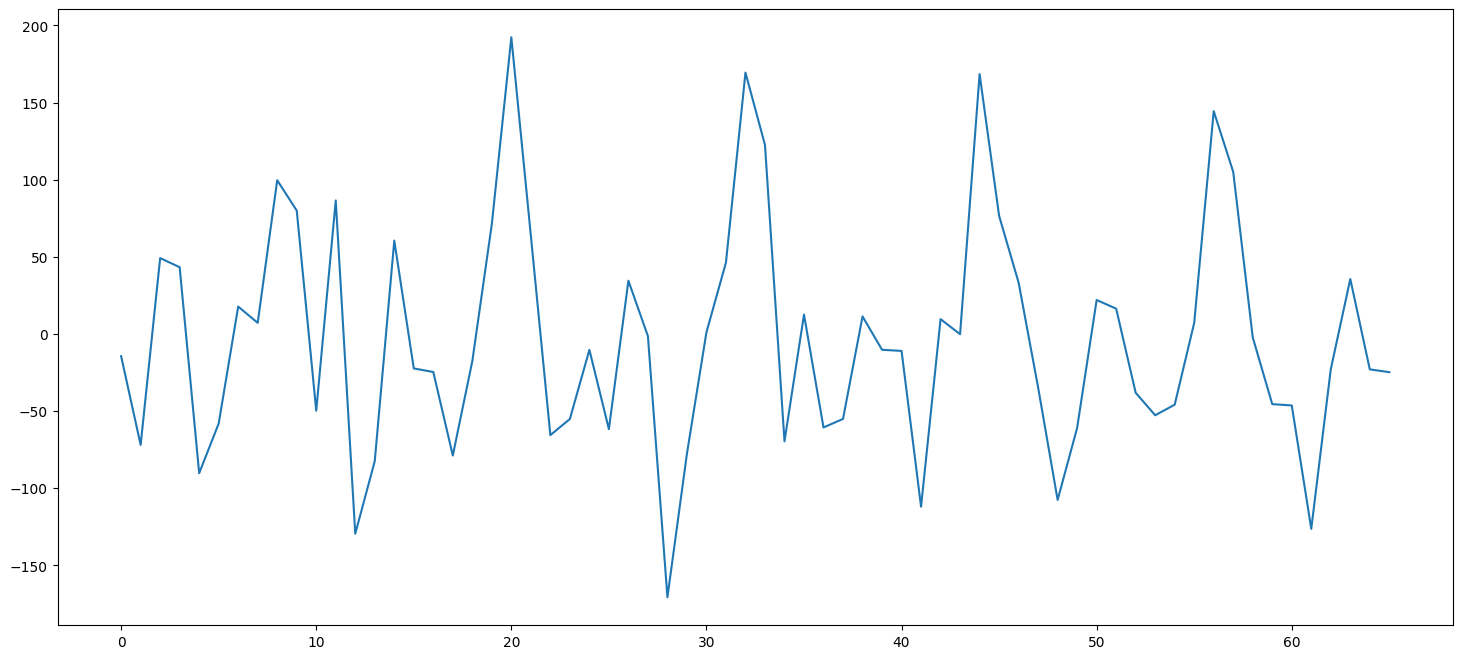

In [49]:
ts_t_adj=difference(ts_month_avg)
ts_t_adj=ts_t_adj.dropna()
ts_t_adj.plot()

In [20]:
adf_test = adfuller(ts_t_adj)

print('ADF Statistic: %f' % adf_test[0])
print('Critical Values @ 0.05: %.2f' % adf_test[4]['5%'])
print('p-value: %f' % adf_test[1])

ADF Statistic: -6.795995
Critical Values @ 0.05: -2.92
p-value: 0.000000


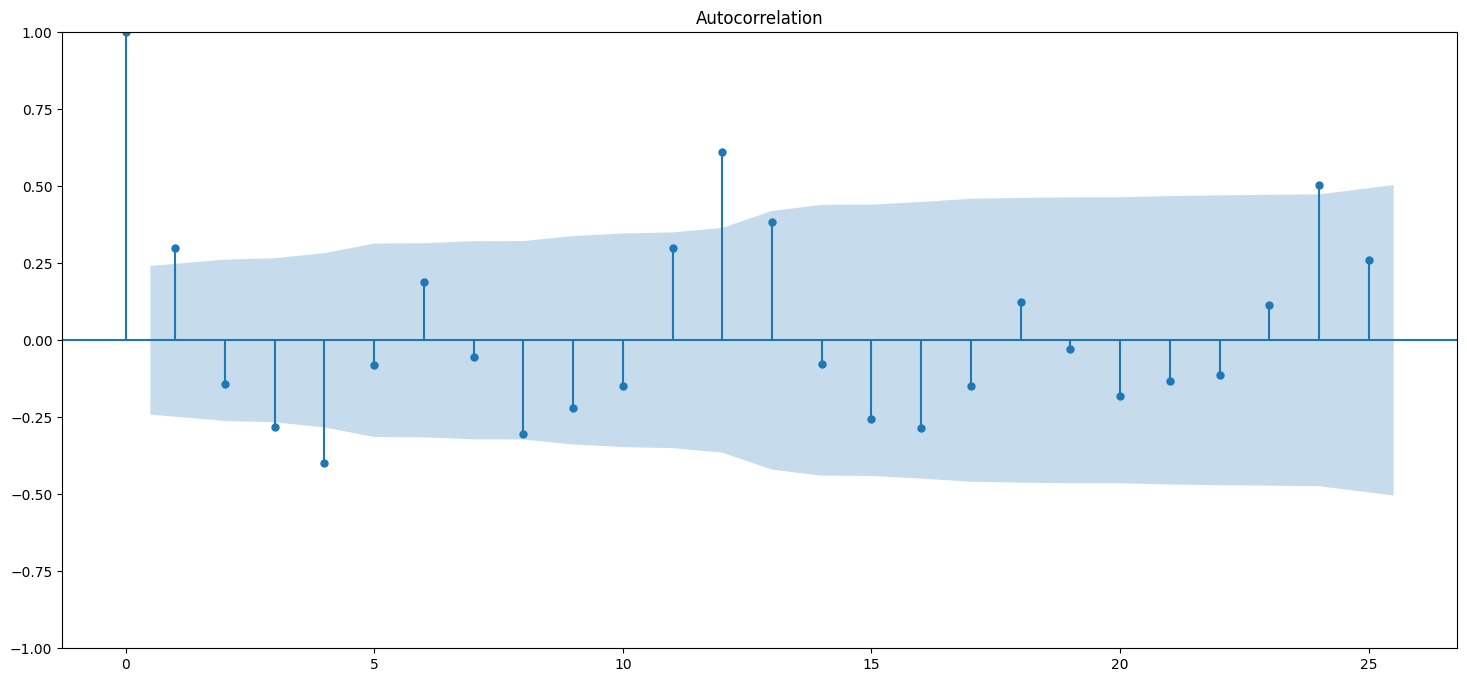

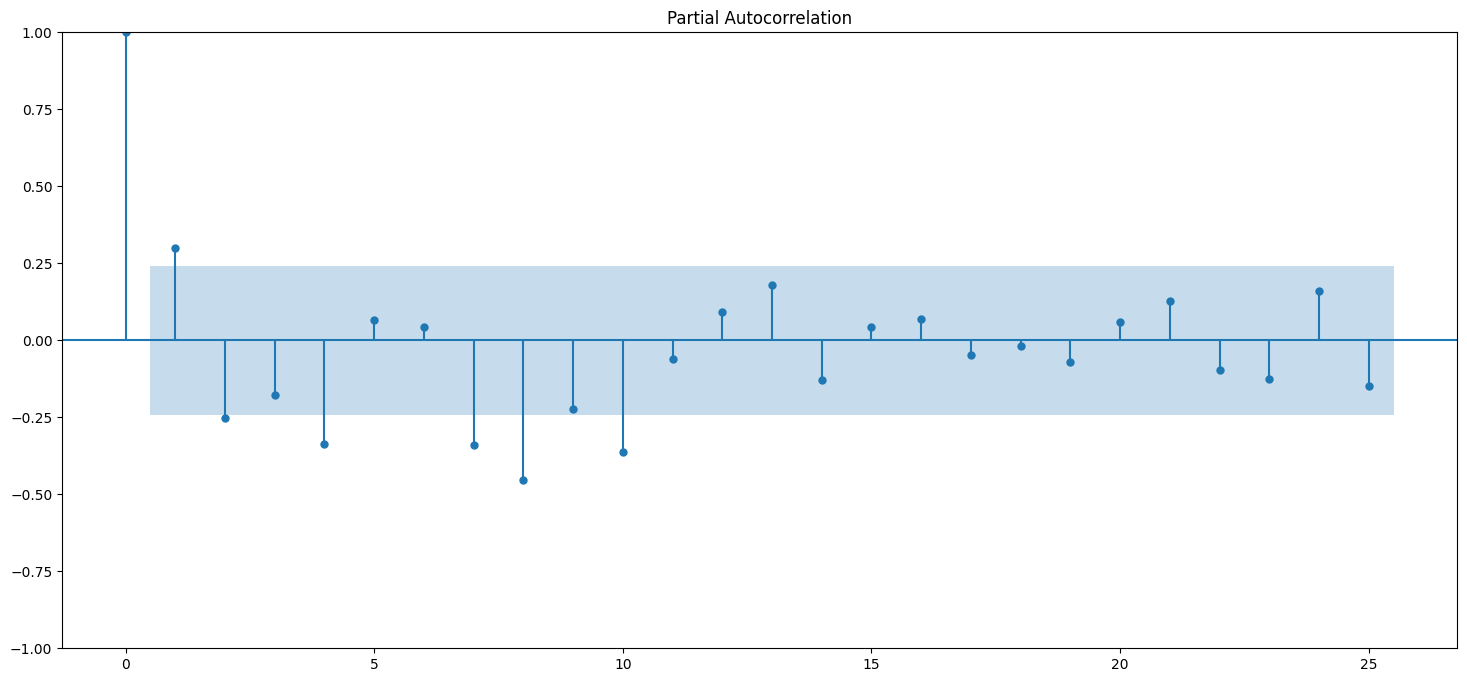

In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts_t_adj,lags=25)
plot_pacf(ts_t_adj,lags=25)
plt.show()

In [23]:
train = ts_month_avg[0:54]
test = ts_month_avg[54:]
print('Train Timeseries Range => ', train.index.min(), ' - ' , train.index.max())
print('Test Timeseries Range => ', test.index.min(), ' - ' , test.index.max())

Train Timeseries Range =>  2015-01-01 00:00:00  -  2019-06-01 00:00:00
Test Timeseries Range =>  2019-07-01 00:00:00  -  2020-07-01 00:00:00


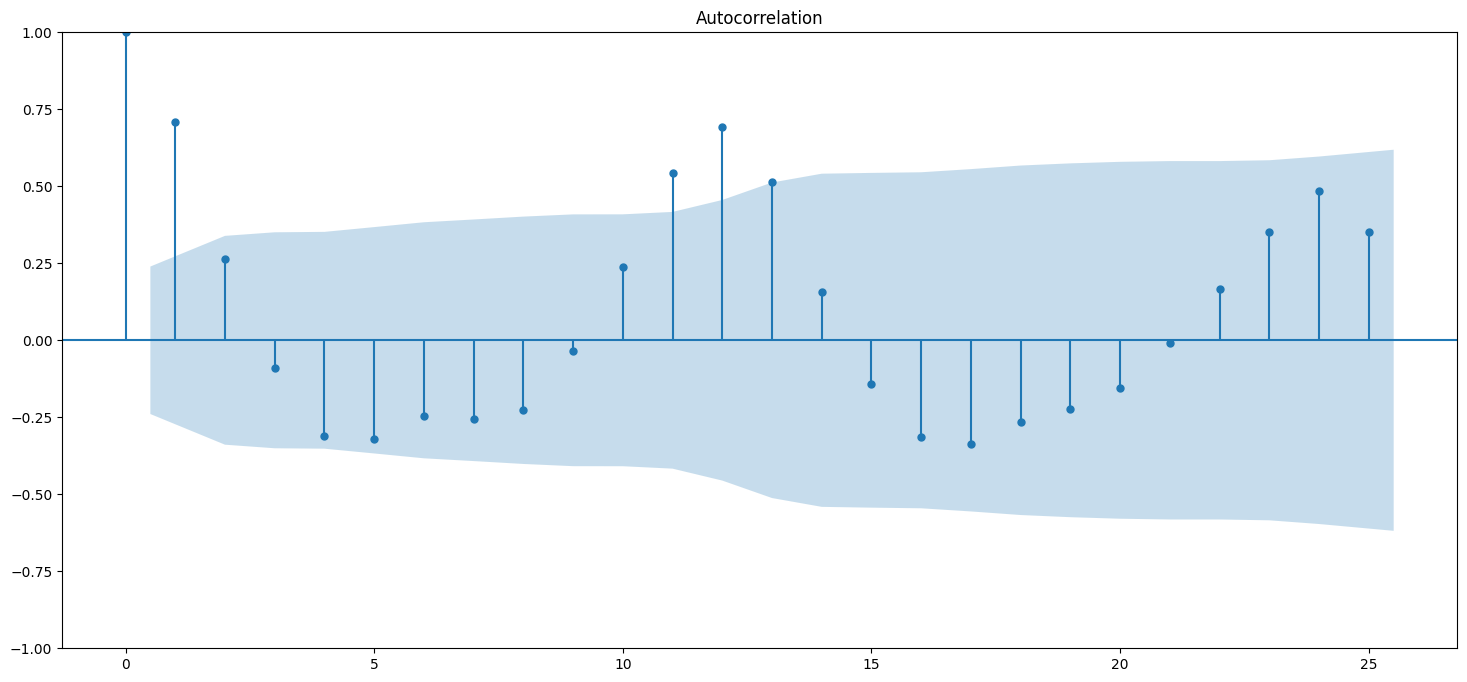

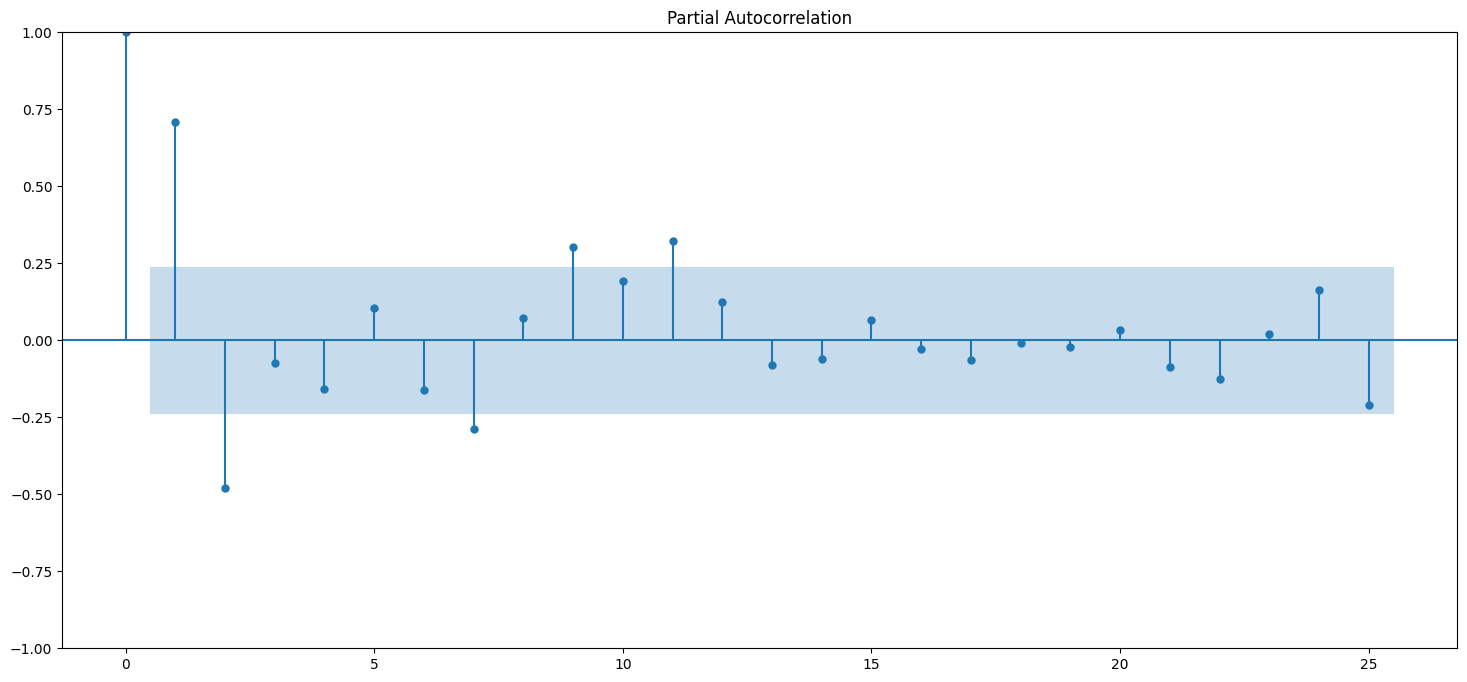

In [24]:
plot_acf(ts_month_avg,lags=25)
plot_pacf(ts_month_avg,lags=25)
plt.show()

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train,order=(1,1,1), seasonal_order=(1,0,1,12),
                                 enforce_stationarity=False, enforce_invertibility=False,)
model = sarima.fit()
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                AQI   No. Observations:                   54
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -202.621
Date:                            Tue, 11 Aug 2026   AIC                            415.243
Time:                                    23:19:27   BIC                            423.561
Sample:                                01-01-2015   HQIC                           418.227
                                     - 06-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4705      0.221      2.126      0.034       0.037       0.904
ma.L1         -1.0000   5083.640   

In [27]:
pred_test = model.predict(start=test.index.min(), end=test.index.max())
pred_test

2019-07-01    108.937050
2019-08-01    104.261965
2019-09-01    129.514668
2019-10-01    270.469487
2019-11-01    347.573554
2019-12-01    311.647910
2020-01-01    314.989298
2020-02-01    247.692036
2020-03-01    183.130572
2020-04-01    213.222649
2020-05-01    217.018175
2020-06-01    155.935887
2020-07-01     82.266482
Freq: MS, Name: predicted_mean, dtype: float64

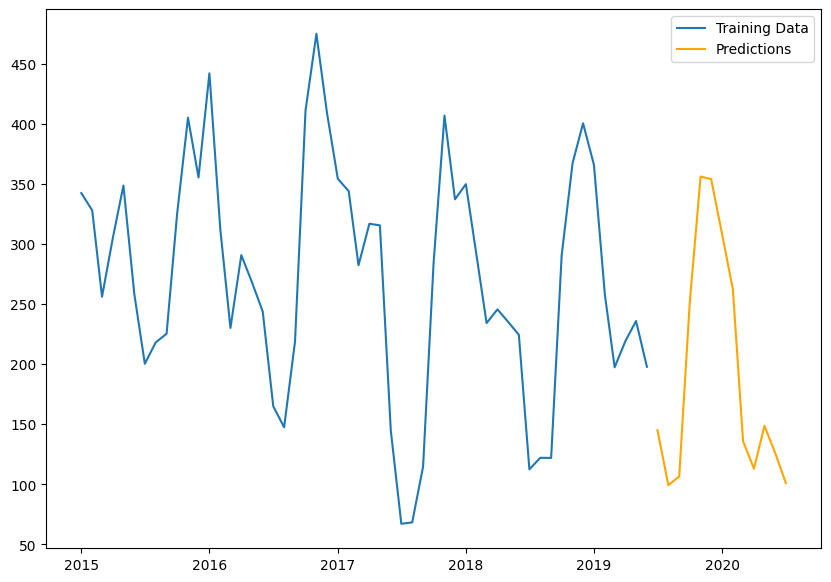

In [28]:
plt.figure(figsize=(10,7))
plt.plot(train.index,train,label='Training Data')
plt.plot(test.index,test, label='Predictions', color='orange')
plt.legend()
plt.show()

In [29]:
ts_month_avg

Date
2015-01-01    342.290323
2015-02-01    327.928571
2015-03-01    256.064516
2015-04-01    305.266667
2015-05-01    348.580645
                 ...    
2020-03-01    135.838710
2020-04-01    113.000000
2020-05-01    148.645161
2020-06-01    125.733333
2020-07-01    101.000000
Freq: MS, Name: AQI, Length: 67, dtype: float64

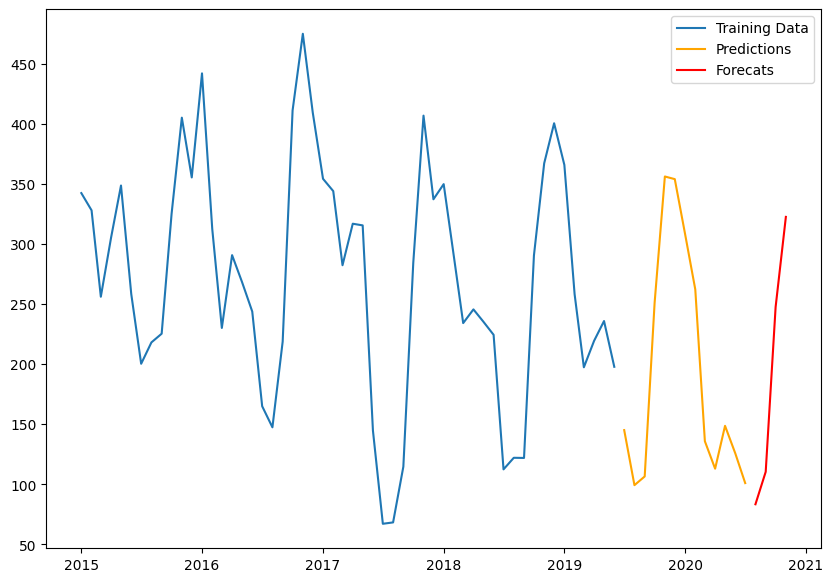

In [30]:
pred_future = model.get_prediction(start=pd.to_datetime('2020-08-01'),end=pd.to_datetime('2020-11-01') ,dynamic=False)
plt.figure(figsize=(10,7))
plt.plot(train.index,train,label='Training Data')
plt.plot(test.index,test, label='Predictions', color='orange')
plt.plot(pred_future.predicted_mean.index,pred_future.predicted_mean.values, label='Forecats', color='red')
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(pred_test,test)
print(mae)

32.32085608316859


In [32]:
sarima_model = auto_arima(train, start_p=0, start_q=0,
                      max_p=12, max_q=12,
                      m=12,             
                      d=None,             
                      start_P=1,
                      start_Q=1,
                      max_P=10,
                      max_Q=10,
                      test='adf',         # use adftest to find optimal 'd'
                      D=None, 
                      seasonal=True,
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=False,
                         information_criterion='aic')

 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=649.483, Time=0.02 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=624.295, Time=0.10 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,0)(0,0,3)[12] intercept   : AIC=inf, Time=0.47 sec
 ARIMA(0,0,0)(0,0,4)[12] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,0,0)(0,0,5)[12] intercept   : AIC=inf, Time=1.91 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=606.491, Time=0.21 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=613.963, Time=0.30 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=0.56 sec
 ARIMA(0,0,0)(1,0,3)[12] intercept   : AIC=inf, Time=0.85 sec
 ARIMA(0,0,0)(1,0,4)[12] intercept   : AIC=inf, Time=1.08 sec
 ARIMA(0,0,0)(2,0,0)[12] intercept   : AIC=606.603, Time=0.38 sec
 ARIMA(0,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(0,0,0)(2,0,3)[12] intercept   : AIC=inf, Time=0.79 sec
 ARIMA(0,0,0)(3,0,0)[12] intercept   : AIC=608.780

In [33]:
print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   54
Model:             SARIMAX(2, 0, 0)x(2, 0, 0, 12)   Log Likelihood                -284.594
Date:                            Tue, 11 Aug 2026   AIC                            581.188
Time:                                    23:22:06   BIC                            593.122
Sample:                                01-01-2015   HQIC                           585.791
                                     - 06-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     20.5598     13.652      1.506      0.132      -6.198      47.317
ar.L1          0.8527      0.165   

In [34]:
auto=SARIMAX(train,order=(1,0,1), seasonal_order=(2,0,0,12),
                                 enforce_stationarity=False, enforce_invertibility=False,)

In [35]:
fitted_2 = auto.fit()
pred_test_new = fitted_2.predict(start=test.index.min(), end=test.index.max())
pred_test_new

2019-07-01    108.844337
2019-08-01     92.831281
2019-09-01    109.412738
2019-10-01    253.576462
2019-11-01    344.016637
2019-12-01    316.329256
2020-01-01    311.472632
2020-02-01    242.863455
2020-03-01    192.742841
2020-04-01    206.200302
2020-05-01    206.039898
2020-06-01    187.513396
2020-07-01     97.168195
Freq: MS, Name: predicted_mean, dtype: float64

In [36]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(pred_test_new,test)
print(mae)

30.24855464663824
